In [3]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [8]:
#Carregamento da base de dados
base_treino = pd.read_csv('/content/base_treino.csv')

Acurácia de treino: 0.6487
Acurácia de teste: 0.5725


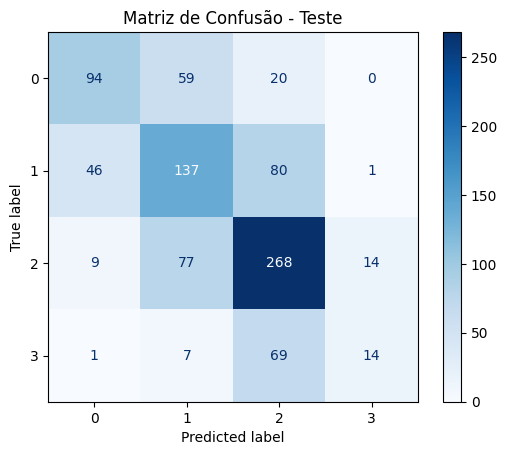

In [11]:
#Segundo modelo Induzido
#KNN ou K-Vizinhos Mais Próximos


# Imputação dos valores ausentes na coluna "Nível"
imputer = SimpleImputer(strategy='mean')
base_treino['Nível'] = imputer.fit_transform(base_treino[['Nível']])

# Separando features (X) e target (y)
X = base_treino.drop('Nivel_Salarial', axis=1)
y = base_treino['Nivel_Salarial']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento do modelo KNN
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

# Previsões
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)

# Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia de treino: {acc_train:.4f}")
print(f"Acurácia de teste: {acc_test:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Teste")
plt.show()


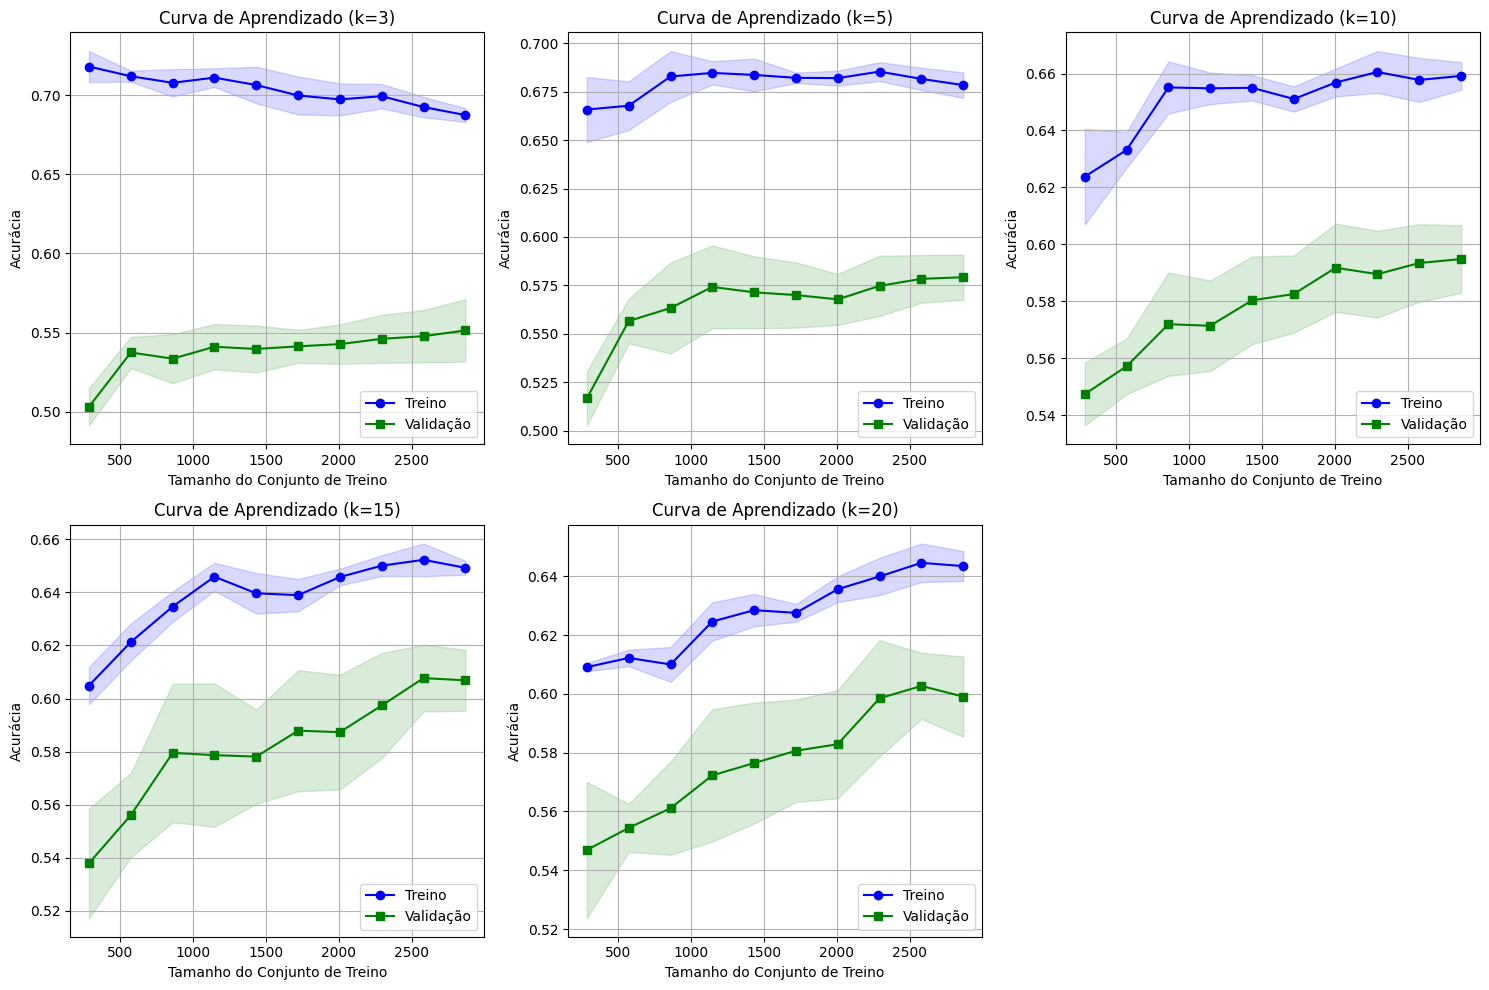

In [10]:
#Teste dos valores de K

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import learning_curve

# Valores de k que serão testados
k_values = [3, 5, 10, 15, 20]  # Incluí k=10 para referência

plt.figure(figsize=(15, 10))  # Tamanho do gráfico

for k in k_values:
    # Cria o modelo KNN com o k atual
    knn = KNeighborsClassifier(n_neighbors=k)

    # Calcula a curva de aprendizado
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=knn,
        X=X_train_scaled,  # Seus dados de treino escalonados
        y=y_train,         # Seus labels de treino
        train_sizes=np.linspace(0.1, 1.0, 10),  # De 10% a 100% dos dados
        cv=5,              # Validação cruzada com 5 folds
        scoring='accuracy',
        n_jobs=-1          # Usa todos os núcleos do processador
    )

    # Calcula médias e desvios padrão
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plota a curva para o k atual
    plt.subplot(2, 3, k_values.index(k) + 1)  # Organiza os subplots

    plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Treino')
    plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

    plt.plot(train_sizes, test_mean, color='green', marker='s', label='Validação')
    plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

    plt.title(f'Curva de Aprendizado (k={k})')
    plt.xlabel('Tamanho do Conjunto de Treino')
    plt.ylabel('Acurácia')
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()  # Ajusta o espaçamento entre subplots
plt.show()